In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [42]:
# 1. Data inlezen
df = pd.read_csv("../data/data_final_with_aadt_and_vulnerability.csv")

# Controleer kolomnamen
print(df.columns)

# 2. Zorg dat lon/lat bestaan (pas namen aan indien nodig)
lon = df['lon']
lat = df['lat']

# 3. Variabelen
variables = ['WMO_WIND_I', 'distance', 'elevation']

Index(['fid', 'field_1', 'road', 'id', 'model_type', 'condition', 'name',
       'lat', 'lon', 'length', 'avg_truck_AADT', 'WMO_WIND_I', 'distance',
       'elevation'],
      dtype='object')


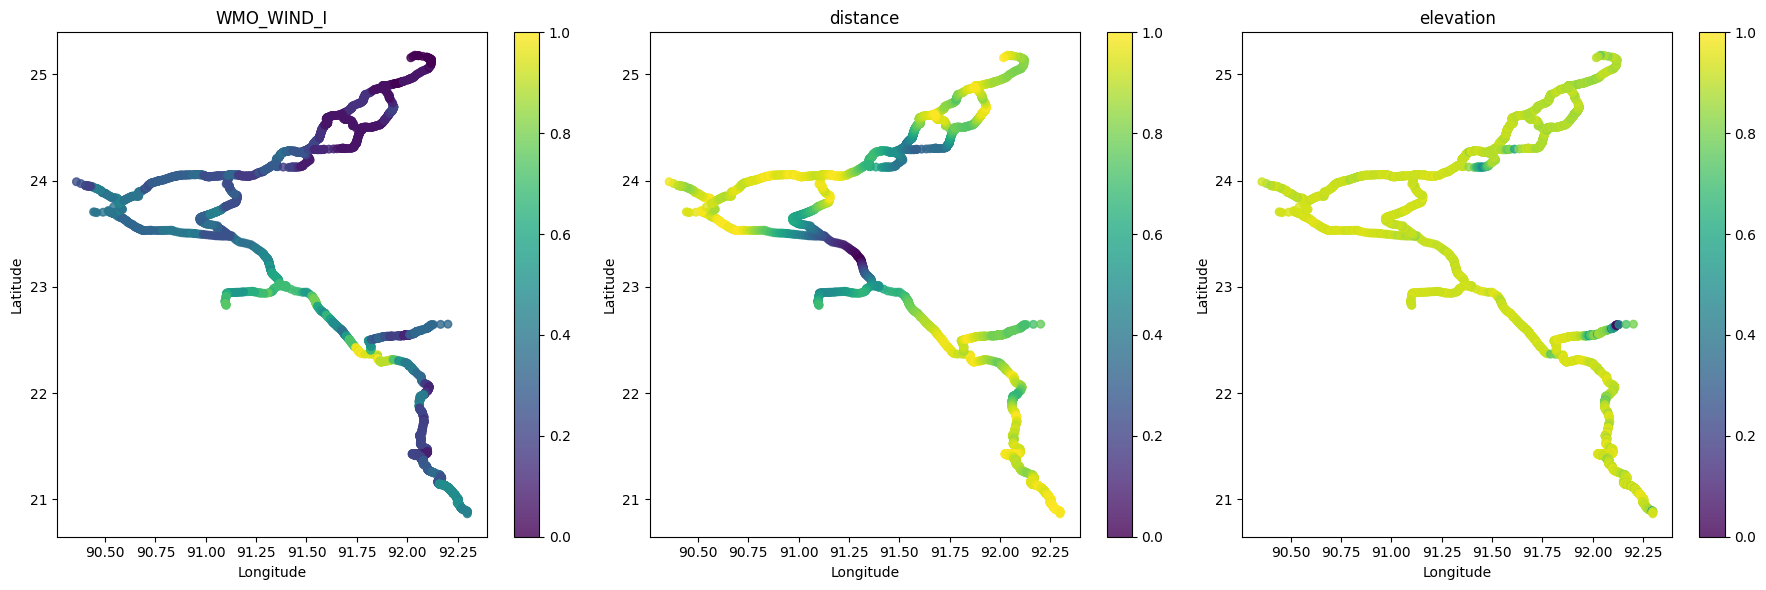

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, variables):
    values = df[var]

    # Normalisatie
    norm = (values - values.min()) / (values.max() - values.min())

    if var in ['distance', 'elevation']:
        colors = 1 - norm  # lage waarde = hoge impact
    else:
        colors = norm

    sc = ax.scatter(lon, lat, c=colors, cmap='viridis', s=30, alpha=0.8)

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

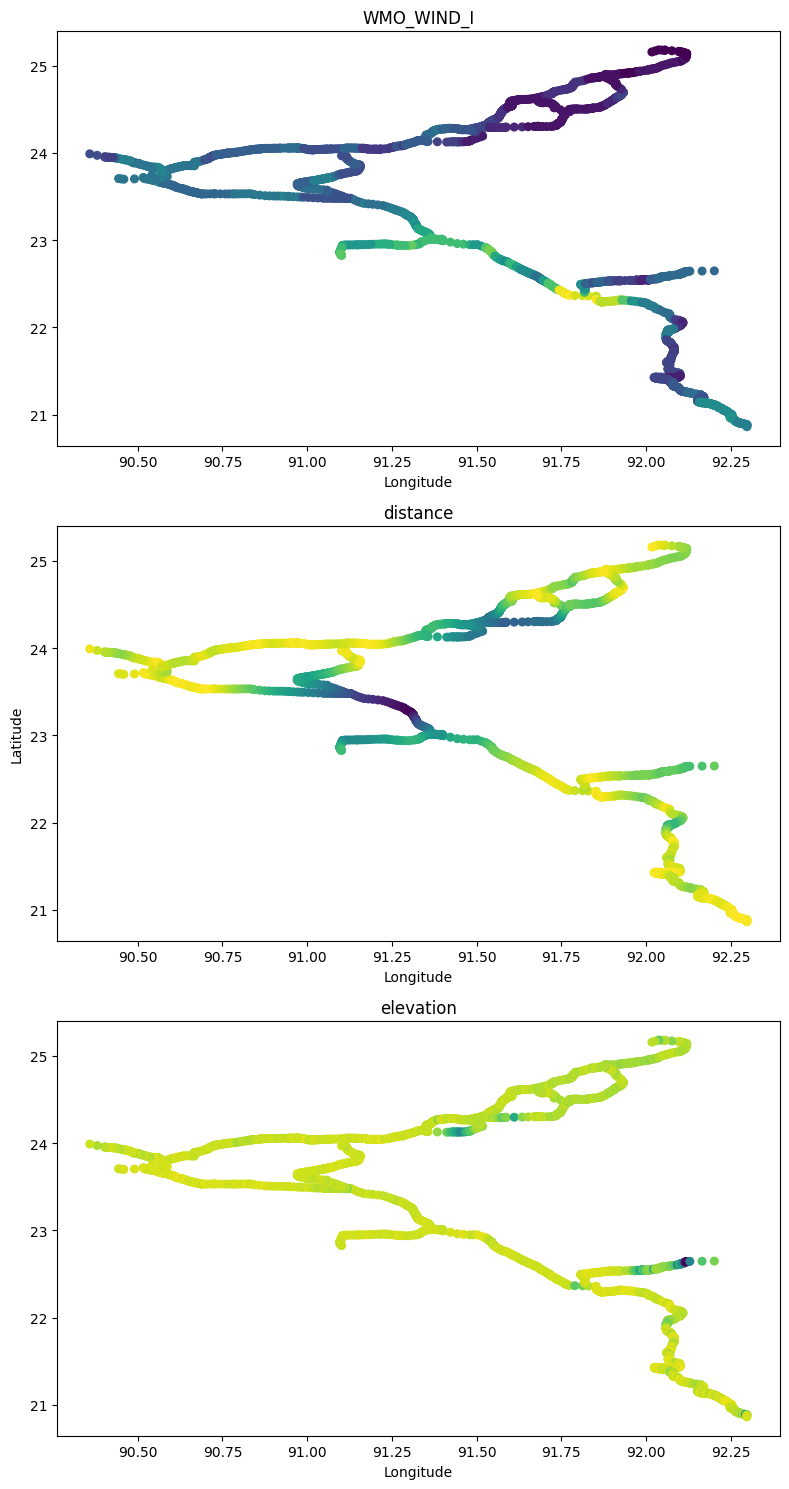

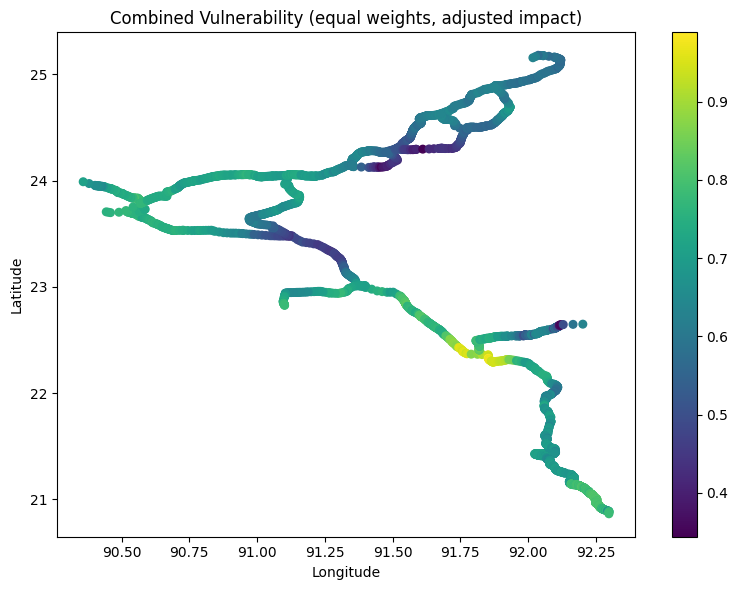

In [44]:
# Zorg dat img map bestaat
os.makedirs("img", exist_ok=True)

# ====== 1. SUBPLOTS ======
fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharey=True)

# Witte achtergrond
fig.patch.set_facecolor('white')

for ax, var in zip(axes, variables):
    values = df[var]

    # Normaliseren
    norm = (values - values.min()) / (values.max() - values.min())

    if var in ['distance', 'elevation']:
        colors = 1 - norm  # lage waarde = hoge impact
    else:
        colors = norm

    sc = ax.scatter(lon, lat, c=colors, cmap='viridis', s=30)

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_facecolor('white')

# Eén gedeelde y-label (in het midden)
axes[1].set_ylabel("Latitude")

plt.tight_layout()

# plt.savefig("img/subplots_vulnerability.png", dpi=300, facecolor='white')
plt.show()


# ====== 2. GECOMBINEERDE VULNERABILITY ======

# Normalisaties
norm_wind = (df['WMO_WIND_I'] - df['WMO_WIND_I'].min()) / (df['WMO_WIND_I'].max() - df['WMO_WIND_I'].min())
norm_dist = (df['distance'] - df['distance'].min()) / (df['distance'].max() - df['distance'].min())
norm_elev = (df['elevation'] - df['elevation'].min()) / (df['elevation'].max() - df['elevation'].min())

# Impact logica toepassen
impact_wind = norm_wind          # hoog = slecht
impact_dist = 1 - norm_dist      # laag = slecht
impact_elev = 1 - norm_elev      # laag = slecht

# Equal weights (1/3)
vulnerability = (impact_wind + impact_dist + impact_elev) / 3

# Plot
plt.figure(figsize=(8, 6))
plt.gcf().patch.set_facecolor('white')

sc = plt.scatter(lon, lat, c=vulnerability, cmap='viridis', s=30)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Combined Vulnerability (equal weights, adjusted impact)")

plt.colorbar(sc)

plt.tight_layout()

# Opslaan
plt.savefig("img/combined_vulnerability.png", dpi=300, facecolor='white')
plt.show()

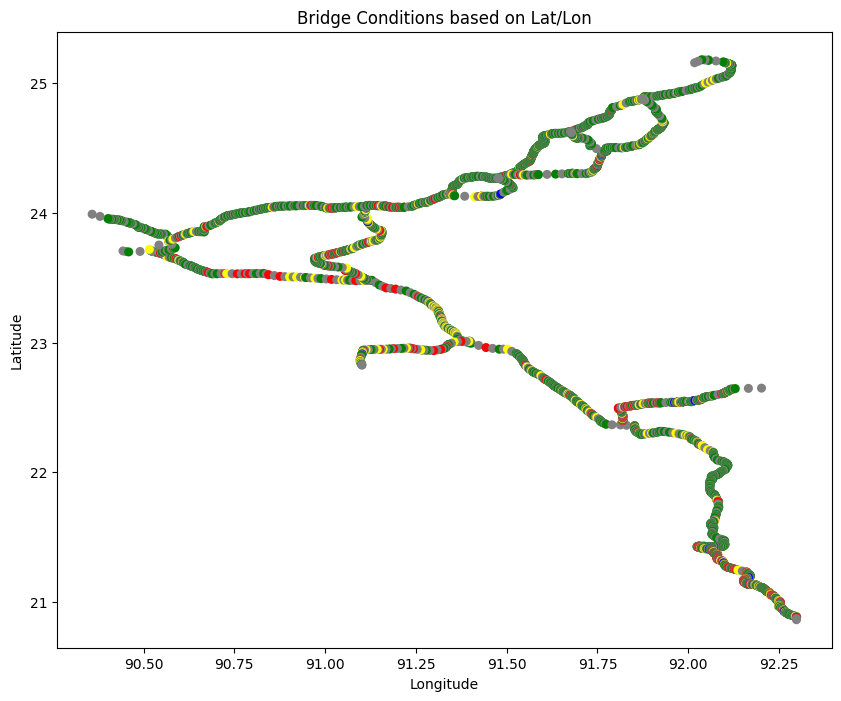

In [45]:
import matplotlib.pyplot as plt

# Maak een kleurmapping
color_dict = {
    'A': 'green',
    'B': 'yellow',
    'C': 'red',
    'D': 'blue'
}

# Vervang NaN door 'unknown'
conditions_filled = df['condition'].fillna('unknown')

# Voeg 'unknown' toe aan color_dict
color_dict['unknown'] = 'gray'

# Map categorieën naar kleuren en converteer naar string lijst
colors = [color_dict[str(c)] for c in conditions_filled]

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(df['lon'], df['lat'], c=colors, s=30)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Bridge Conditions based on Lat/Lon")
plt.show()

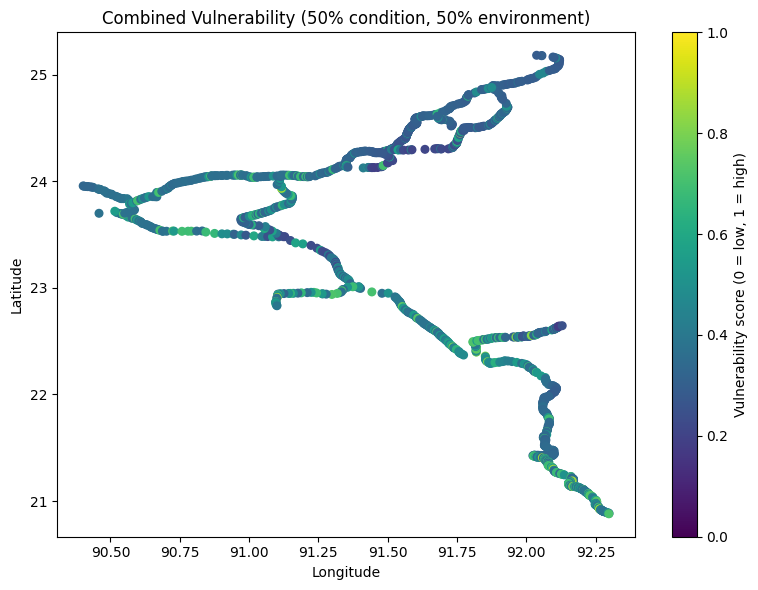

In [46]:
condition_map = {
    'A': 0.0,
    'B': 0.33,
    'C': 0.66,
    'D': 1.0
}

df['condition_score'] = df['condition'].map(condition_map)

# Normalisaties
norm_wind = (df['WMO_WIND_I'] - df['WMO_WIND_I'].min()) / (df['WMO_WIND_I'].max() - df['WMO_WIND_I'].min())
norm_dist = (df['distance'] - df['distance'].min()) / (df['distance'].max() - df['distance'].min())
norm_elev = (df['elevation'] - df['elevation'].min()) / (df['elevation'].max() - df['elevation'].min())

# Impact logica
impact_wind = norm_wind
impact_dist = 1 - norm_dist
impact_elev = 1 - norm_elev

# Deze drie samen (50%)
infra_vulnerability = (impact_wind + impact_dist + impact_elev) / 3

vulnerability_total = 0.5 * infra_vulnerability + 0.5 * df['condition_score']

plt.figure(figsize=(8, 6))
plt.gcf().patch.set_facecolor('white')

sc = plt.scatter(lon, lat, c=vulnerability_total, cmap='viridis', s=30, vmin=0, vmax=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Combined Vulnerability (50% condition, 50% environment)")

cbar = plt.colorbar(sc)
cbar.set_label("Vulnerability score (0 = low, 1 = high)")

plt.tight_layout()

plt.savefig("img/combined_vulnerability_with_condition.png", dpi=300, facecolor='white')
plt.show()